In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, f_oneway

data= pd.read_csv('D:/college/3rd term/Github/FCDS-3rd-Term/probability/2017_Yellow_Taxi_Trip_Data.csv')
df =pd.DataFrame(data)

In [61]:
np.random.seed(42)
dff = pd.DataFrame({
    "Group": np.random.choice(["A", "B", "C"], size=30),
    "Value": np.random.normal(loc=50, scale=10, size=30),
})
print(df.head())

   Unnamed: 0  VendorID    tpep_pickup_datetime   tpep_dropoff_datetime  \
0    24870114         2   03/25/2017 8:55:43 AM   03/25/2017 9:09:47 AM   
1    35634249         1   04/11/2017 2:53:28 PM   04/11/2017 3:19:58 PM   
2   106203690         1   12/15/2017 7:26:56 AM   12/15/2017 7:34:08 AM   
3    38942136         2   05/07/2017 1:17:59 PM   05/07/2017 1:48:14 PM   
4    30841670         2  04/15/2017 11:32:20 PM  04/15/2017 11:49:03 PM   

   passenger_count  trip_distance  RatecodeID store_and_fwd_flag  \
0                6           3.34           1                  N   
1                1           1.80           1                  N   
2                1           1.00           1                  N   
3                1           3.70           1                  N   
4                1           4.37           1                  N   

   PULocationID  DOLocationID  payment_type  fare_amount  extra  mta_tax  \
0           100           231             1         13.0    0.0 

In [62]:
mean_value = dff["Value"].mean()
median_value = dff["Value"].median()
skewness = skew(dff["Value"])
kurt = kurtosis(dff["Value"], fisher=False)

print(f"Mean: {mean_value}")
print(f"Median: {median_value}")
print(f"Skewness: {skewness}")
print(f"Kurtosis: {kurt}")

Mean: 49.832603872371536
Median: 48.04397079885261
Skewness: 0.7009229630539425
Kurtosis: 3.700182600620239


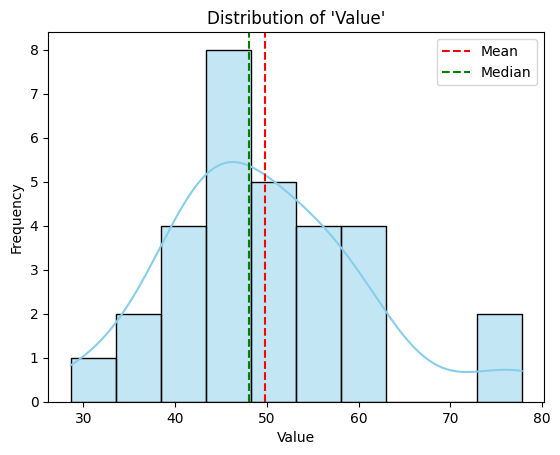

In [63]:
# Plot histogram
sns.histplot(dff["Value"], kde=True, bins=10, color="skyblue")
plt.axvline(mean_value, color="red", linestyle="--", label="Mean")
plt.axvline(median_value, color="green", linestyle="--", label="Median")
plt.title("Distribution of 'Value'")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()



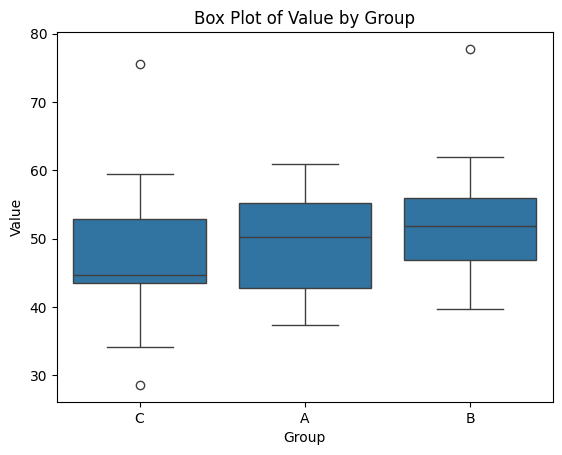

In [64]:
sns.boxplot(x="Group", y="Value", data=dff)
plt.title("Box Plot of Value by Group")
plt.xlabel("Group")
plt.ylabel("Value")
plt.show()

In [65]:
group_a = dff[dff["Group"] == "A"]["Value"]
group_b = dff[dff["Group"] == "B"]["Value"]
group_c = dff[dff["Group"] == "C"]["Value"]

anova_result = f_oneway(group_a, group_b, group_c)
print(f"ANOVA F-statistic: {anova_result.statistic}")
print(f"ANOVA p-value: {anova_result.pvalue}")

ANOVA F-statistic: 0.7407512204794692
ANOVA p-value: 0.4861963905937711
